In [1]:
import sys
from pathlib import Path

# Add project root to path
sys.path.insert(0, str(Path.cwd().parent))

from db_connection import connect_to_mongodb
connect_to_mongodb()

print("Connected to MongoDB!")

Connected to MongoDB!


In [2]:
import pandas as pd
from products.models import Product
from products.category_model import ProductCategory

# Fetch all products
products = Product.objects.all()

data = []
for p in products:
    try:
        category_title = p.category.title if p.category else "Unknown"
    except Exception:
        category_title = "Unknown"
    data.append({
        "Name": p.name,
        "Category": category_title,
        "Brand": p.brand,
        "Price": float(str(p.price)),
        "Stock": p.quantity_in_warehouse,
    })

df = pd.DataFrame(data)
print(f"Total products: {len(df)}")
df

Total products: 24


,Name,Category,Brand,Price,Stock
0,Samsung TV,Electronics,Samsung,45000.0,10
1,Wheat Bread,Food,Local,50.0,100
2,Coffee Maker,Kitchen Essentials,Philips,3500.0,25
3,iPhone 14,Electronics,Apple,80000.0,15
4,Bluetooth Speaker,Electronics,Boat,2500.0,40
5,Jeans,Clothing,Levis,2000.0,30
6,T-Shirt,Clothing,Nike,800.0,50
7,Jacket,Clothing,Puma,3500.0,20
8,Sneakers,Clothing,Adidas,4000.0,35
9,Rice,Food,India Gate,600.0,60


Matplotlib is building the font cache; this may take a moment.


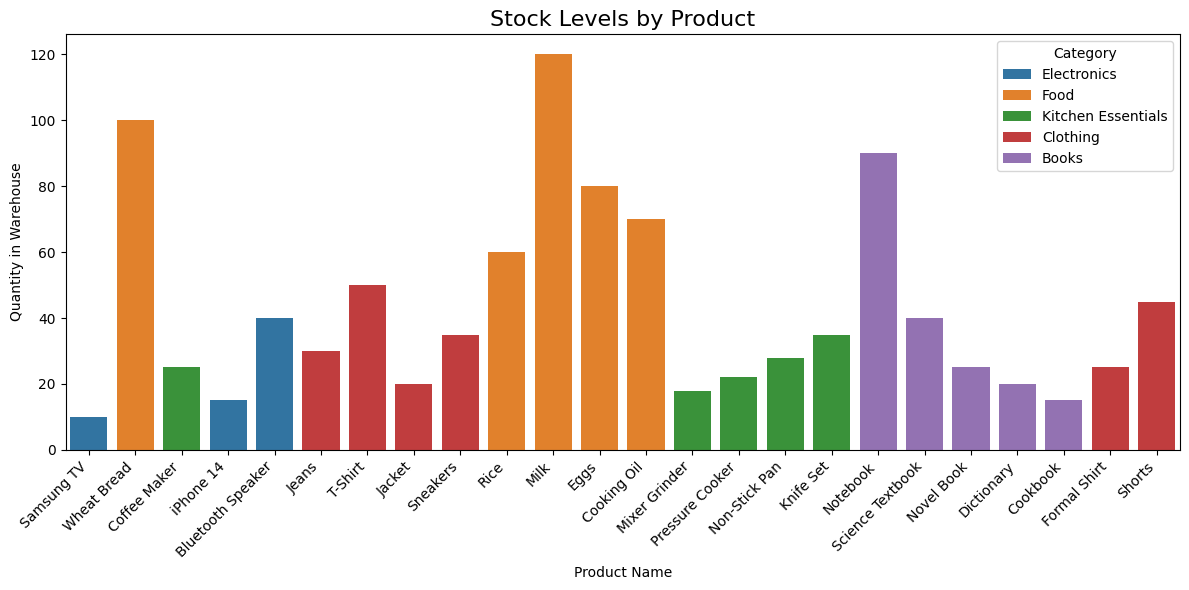

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

if not df.empty:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    sns.barplot(
        data=df,
        x="Name",
        y="Stock",
        hue="Category",
        ax=ax
    )
    
    ax.set_title("Stock Levels by Product", fontsize=16)
    ax.set_xlabel("Product Name")
    ax.set_ylabel("Quantity in Warehouse")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No products found!")

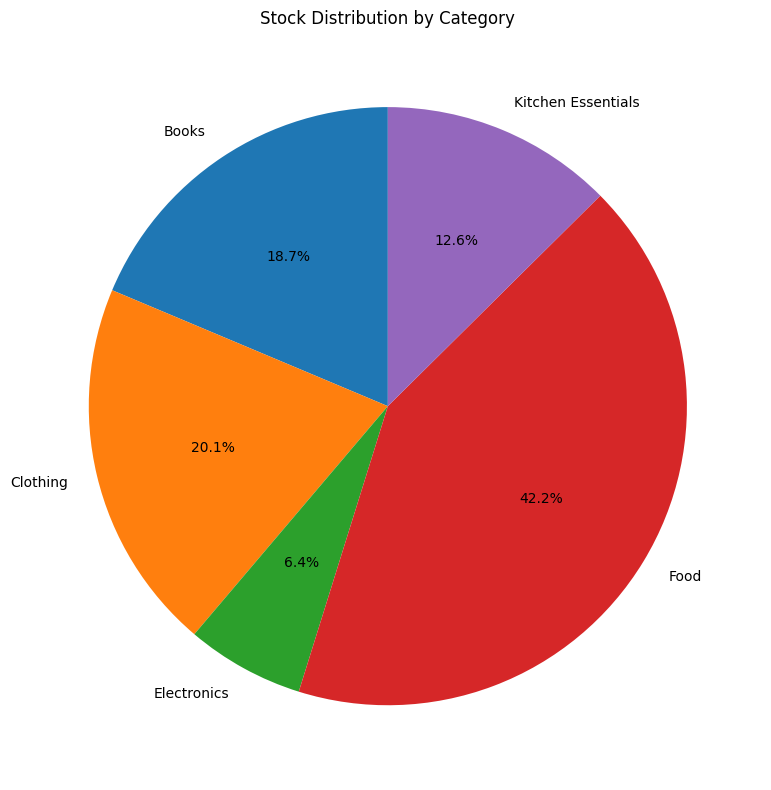

In [4]:
if not df.empty:
    category_stock = df.groupby("Category")["Stock"].sum().reset_index()
    
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.pie(
        category_stock["Stock"],
        labels=category_stock["Category"],
        autopct='%1.1f%%',
        startangle=90
    )
    ax.set_title("Stock Distribution by Category")
    plt.tight_layout()
    plt.show()

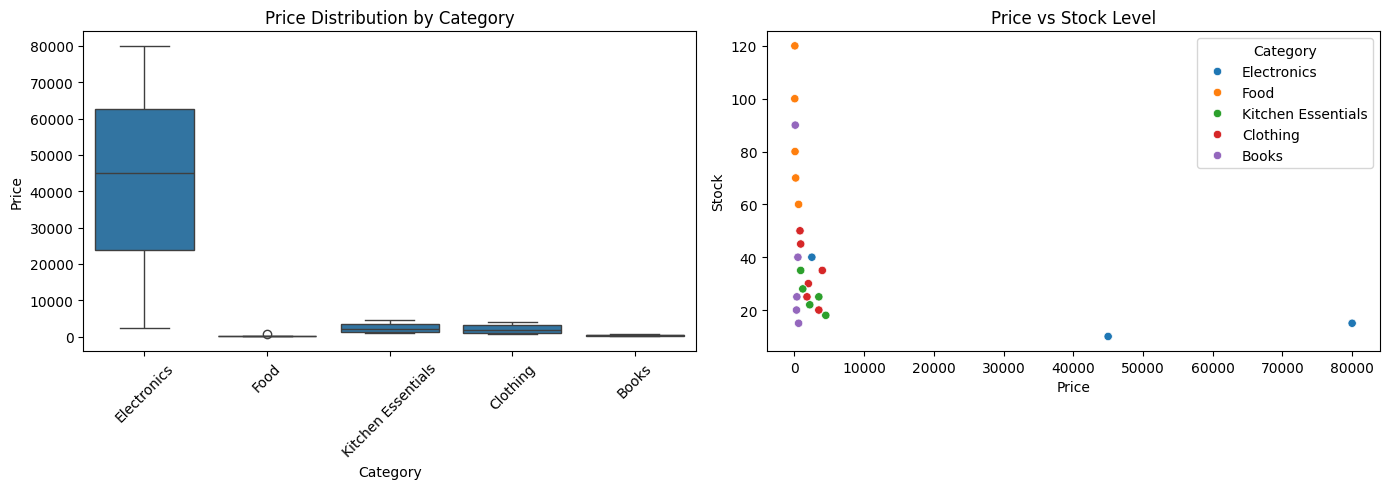

In [5]:
if not df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Price by category
    sns.boxplot(data=df, x="Category", y="Price", ax=axes[0])
    axes[0].set_title("Price Distribution by Category")
    axes[0].tick_params(axis='x', rotation=45)
    
    # Price vs Stock scatter
    sns.scatterplot(data=df, x="Price", y="Stock", hue="Category", ax=axes[1])
    axes[1].set_title("Price vs Stock Level")
    
    plt.tight_layout()
    plt.show()